# 01 - Data Exploration

## Nuclei Segmentation in Histopathology Images

This notebook explores the MoNuSeg and TNBC datasets used in our POC.

**What we'll cover:**
- Loading and visualizing H&E stained images
- Understanding ground truth masks
- Image statistics (size, intensity distributions)
- Dataset characteristics comparison

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.measure import label, regionprops

from src.utils.data_loader import load_dataset, load_all_datasets
from src.utils.visualization import show_image_and_mask, show_pipeline_steps

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Path to data directory (adjust if needed)
DATA_ROOT = '../../data'

print('Setup complete!')

Setup complete!


## 1. Load Both Datasets

In [2]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
datasets = {
    'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}
}
print(f"Loaded monuseg_full: {len(images_all)} images, resolution {images_all[0].shape[1]}x{images_all[0].shape[0]}")

for name, data in datasets.items():
    print(f"\nDataset: {name.upper()}")
    print(f"  Number of images: {len(data['images'])}")
    print(f"  Image shape: {data['images'][0].shape}")
    print(f"  Mask shape: {data['masks'][0].shape}")
    print(f"  Image dtype: {data['images'][0].dtype}")
    print(f"  Mask unique values: {np.unique(data['masks'][0])}")

Loaded monuseg_full: 37 images, resolution 1000x1000

Dataset: MONUSEG_FULL
  Number of images: 37
  Image shape: (1000, 1000, 3)
  Mask shape: (1000, 1000)
  Image dtype: uint8
  Mask unique values: [0 1]


## 2. Visualize Sample Images

H&E (Hematoxylin and Eosin) staining is the most common staining method:
- **Hematoxylin** stains nuclei **blue/purple**
- **Eosin** stains cytoplasm and extracellular matrix **pink**

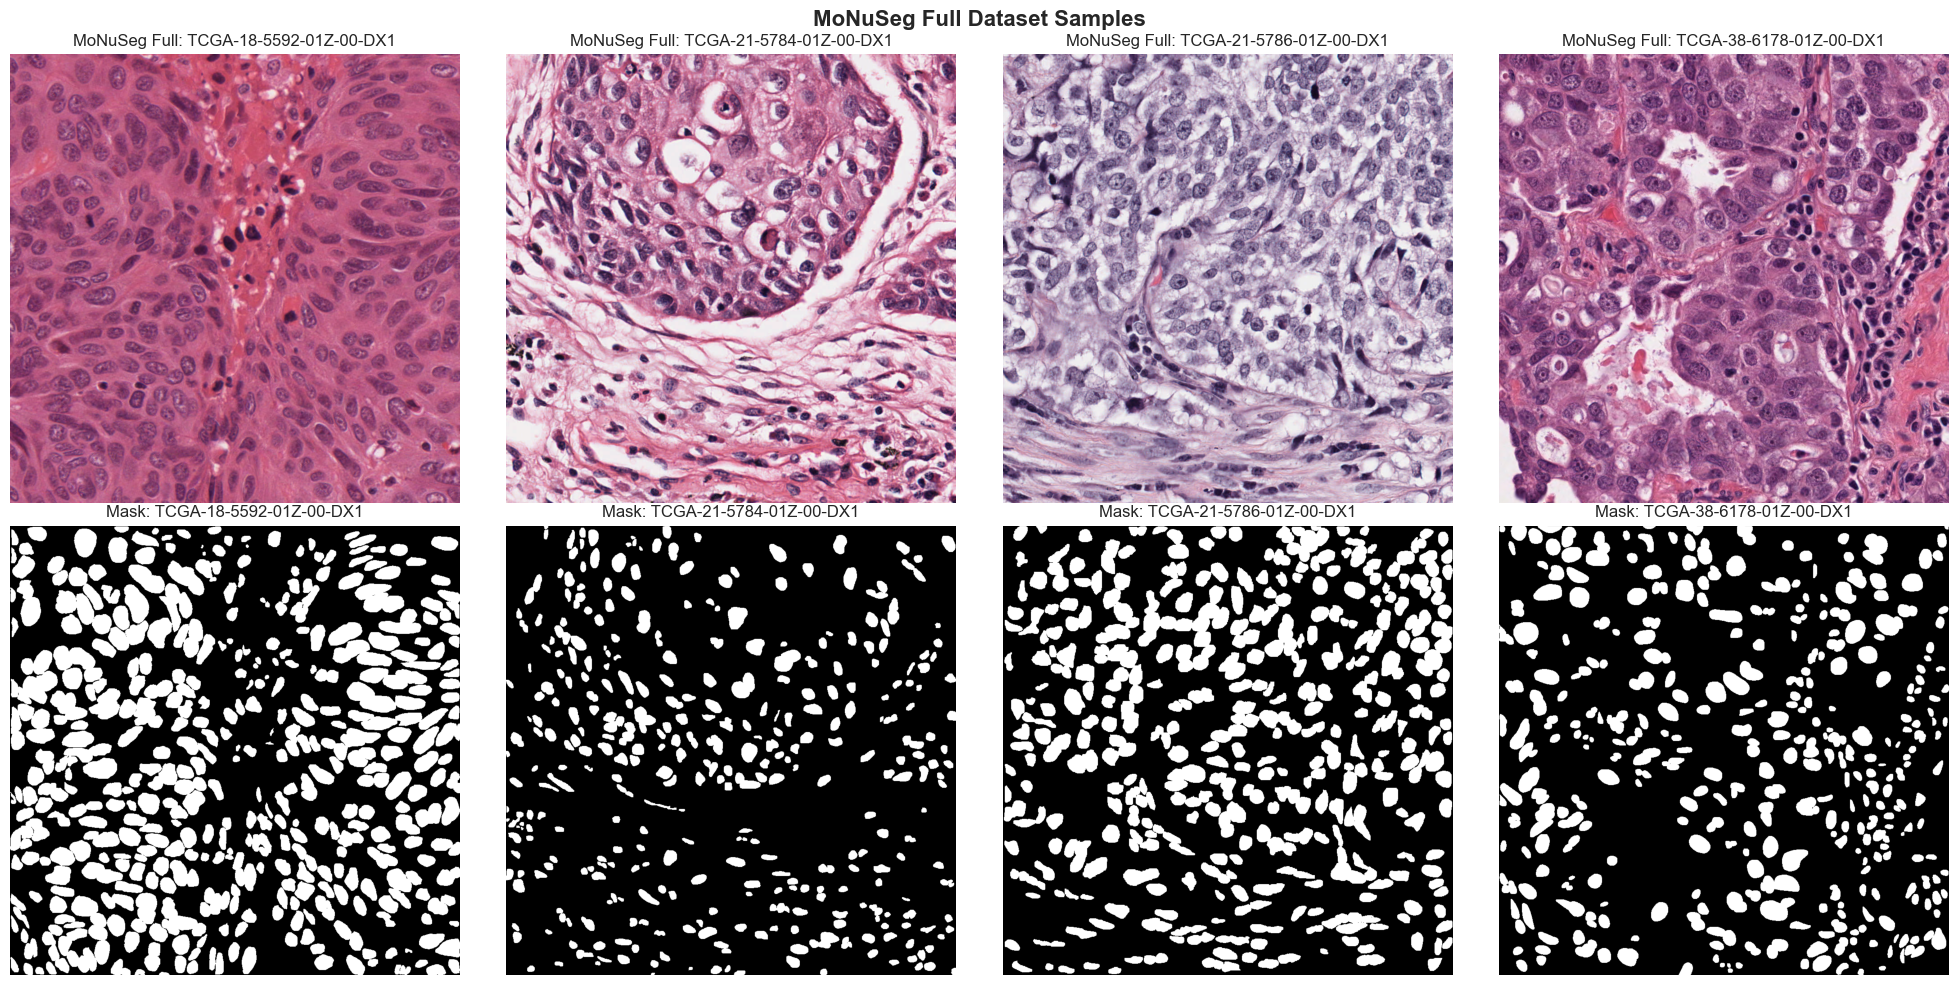

In [3]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Show samples from MoNuSeg Full
if 'monuseg_full' in datasets:
    monuseg = datasets['monuseg_full']
    n_show = min(4, len(monuseg['images']))
    
    fig, axes = plt.subplots(2, n_show, figsize=(5*n_show, 10))
    for i in range(n_show):
        axes[0, i].imshow(monuseg['images'][i])
        axes[0, i].set_title(f"MoNuSeg Full: {monuseg['names'][i]}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(monuseg['masks'][i], cmap='gray')
        axes[1, i].set_title(f"Mask: {monuseg['names'][i]}")
        axes[1, i].axis('off')
    
    plt.suptitle('MoNuSeg Full Dataset Samples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [4]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# TNBC dataset skipped for now - using monuseg_full only
print("TNBC dataset skipped - focusing on monuseg_full dataset")

TNBC dataset skipped - focusing on monuseg_full dataset


## 3. Image Statistics

Let's analyze the color distributions and nuclei characteristics.

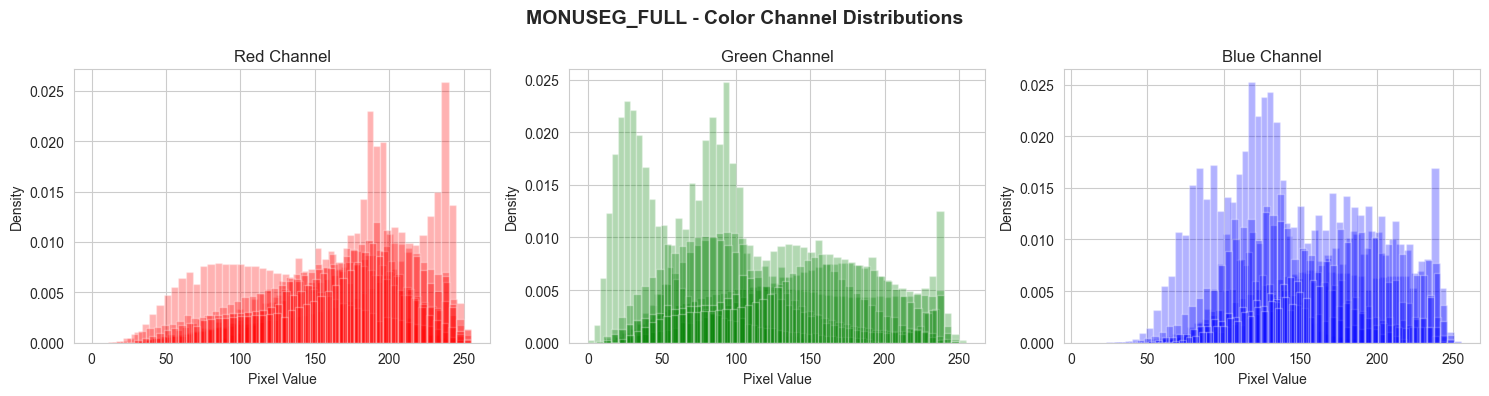

In [5]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Color channel distributions
for ds_name, data in datasets.items():
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    channel_names = ['Red', 'Green', 'Blue']
    colors = ['red', 'green', 'blue']
    
    for ch in range(3):
        for i, img in enumerate(data['images'][:8]):
            axes[ch].hist(img[:,:,ch].ravel(), bins=50, alpha=0.3, 
                         color=colors[ch], density=True)
        axes[ch].set_title(f'{channel_names[ch]} Channel')
        axes[ch].set_xlabel('Pixel Value')
        axes[ch].set_ylabel('Density')
    
    plt.suptitle(f'{ds_name.upper()} - Color Channel Distributions', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [6]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Nuclei statistics per image
import pandas as pd

all_stats = []
for ds_name, data in datasets.items():
    for i, (mask, name) in enumerate(zip(data['masks'], data['names'])):
        labeled = label(mask)
        props = regionprops(labeled)
        areas = [p.area for p in props]
        
        stats = {
            'Dataset': ds_name.upper(),
            'Image': name,
            'Num Nuclei': len(props),
            'Mean Area': np.mean(areas) if areas else 0,
            'Std Area': np.std(areas) if areas else 0,
            'Nuclei Density (%)': 100 * np.sum(mask > 0) / mask.size,
            'Image Width': data['images'][i].shape[1],
            'Image Height': data['images'][i].shape[0],
        }
        all_stats.append(stats)

df_stats = pd.DataFrame(all_stats)
print("\nPer-Image Statistics:")
print(df_stats.to_string(index=False))


Per-Image Statistics:
     Dataset                   Image  Num Nuclei   Mean Area    Std Area  Nuclei Density (%)  Image Width  Image Height
MONUSEG_FULL TCGA-18-5592-01Z-00-DX1         294 1451.401361 1852.772633             42.6712         1000          1000
MONUSEG_FULL TCGA-21-5784-01Z-00-DX1         331  415.682779  301.474261             13.7591         1000          1000
MONUSEG_FULL TCGA-21-5786-01Z-00-DX1         237 1389.907173 1496.701405             32.9408         1000          1000
MONUSEG_FULL TCGA-38-6178-01Z-00-DX1         319  683.485893  536.170514             21.8032         1000          1000
MONUSEG_FULL TCGA-49-4488-01Z-00-DX1         358  993.360335  744.126668             35.5623         1000          1000
MONUSEG_FULL TCGA-50-5931-01Z-00-DX1         255 1644.764706 1674.245825             41.9415         1000          1000
MONUSEG_FULL TCGA-A7-A13E-01Z-00-DX1         287  605.808362  495.548570             17.3867         1000          1000
MONUSEG_FULL TCGA

In [7]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Summary statistics by dataset

if 'df_stats' not in globals():
    import pandas as pd
    all_stats = []
    for ds_name, data in datasets.items():
        for i, (mask, name) in enumerate(zip(data['masks'], data['names'])):
            labeled = label(mask)
            props = regionprops(labeled)
            areas = [p.area for p in props]
            all_stats.append({
                'Dataset': ds_name.upper(),
                'Image': name,
                'Num Nuclei': len(props),
                'Mean Area': np.mean(areas) if areas else 0,
                'Std Area': np.std(areas) if areas else 0,
                'Nuclei Density (%)': 100 * np.sum(mask > 0) / mask.size,
                'Image Width': data['images'][i].shape[1],
                'Image Height': data['images'][i].shape[0],
            })
    df_stats = pd.DataFrame(all_stats)

print("\nSummary by Dataset:")
summary = df_stats.groupby('Dataset')[['Num Nuclei', 'Mean Area', 'Nuclei Density (%)']].agg(
    ['mean', 'std', 'min', 'max']
)
print(summary.round(2))


Summary by Dataset:
             Num Nuclei                    Mean Area                           \
                   mean     std  min   max      mean     std     min      max   
Dataset                                                                         
MONUSEG_FULL     471.46  275.78  158  1026    703.01  398.81  144.07  1849.34   

             Nuclei Density (%)                      
                           mean   std    min    max  
Dataset                                              
MONUSEG_FULL              26.74  9.82  11.91  42.67  


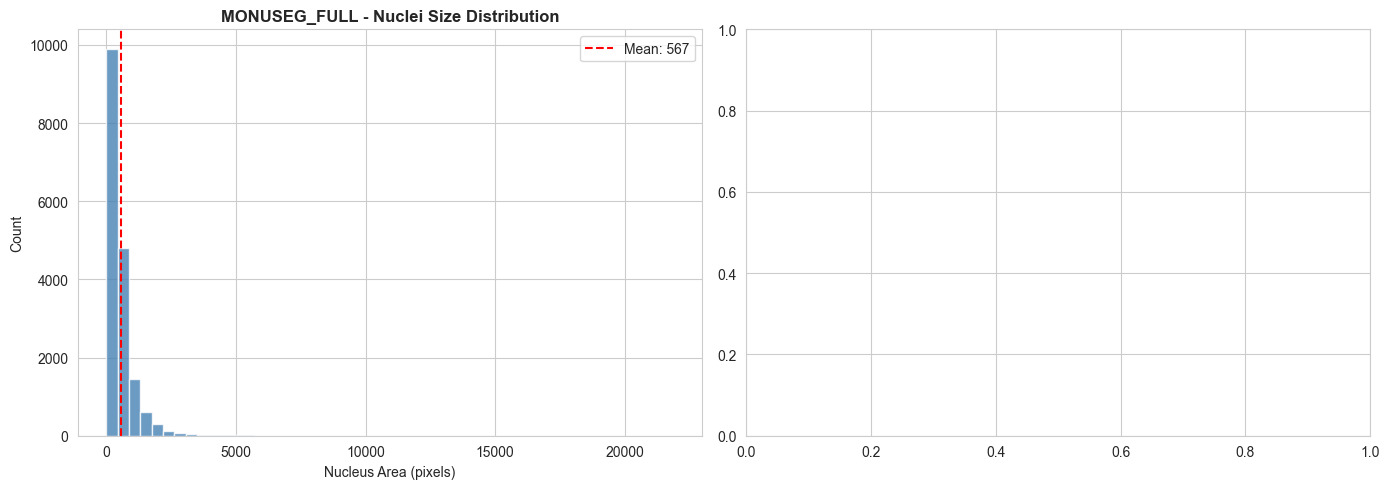


Key Takeaway: Nuclei vary significantly in size, especially in cancer tissue.
This makes fixed thresholding approaches unreliable - motivating adaptive methods.


In [8]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Visualize nuclei size distributions
n_ds = len(datasets)
fig, axes = plt.subplots(1, n_ds, figsize=(7*n_ds, 5))
if n_ds == 1:
    axes = [axes]

for idx, (ds_name, data) in enumerate(datasets.items()):
    all_areas = []
    for mask in data['masks']:
        labeled = label(mask)
        props = regionprops(labeled)
        all_areas.extend([p.area for p in props])
    
    axes[idx].hist(all_areas, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[idx].set_title(f'{ds_name.upper()} - Nuclei Size Distribution', fontweight='bold')
    axes[idx].set_xlabel('Nucleus Area (pixels)')
    axes[idx].set_ylabel('Count')
    axes[idx].axvline(np.mean(all_areas), color='red', linestyle='--', 
                      label=f'Mean: {np.mean(all_areas):.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("\nKey Takeaway: Nuclei vary significantly in size, especially in cancer tissue.")
print("This makes fixed thresholding approaches unreliable - motivating adaptive methods.")

## 4. Staining Variation Challenge

One of the key challenges highlighted in the paper is **staining variation**:
- Different labs use different H&E stain concentrations
- Scanner models produce different color profiles
- Even within a single slide, staining can be inconsistent

This is why **stain normalization** is crucial for automated analysis.

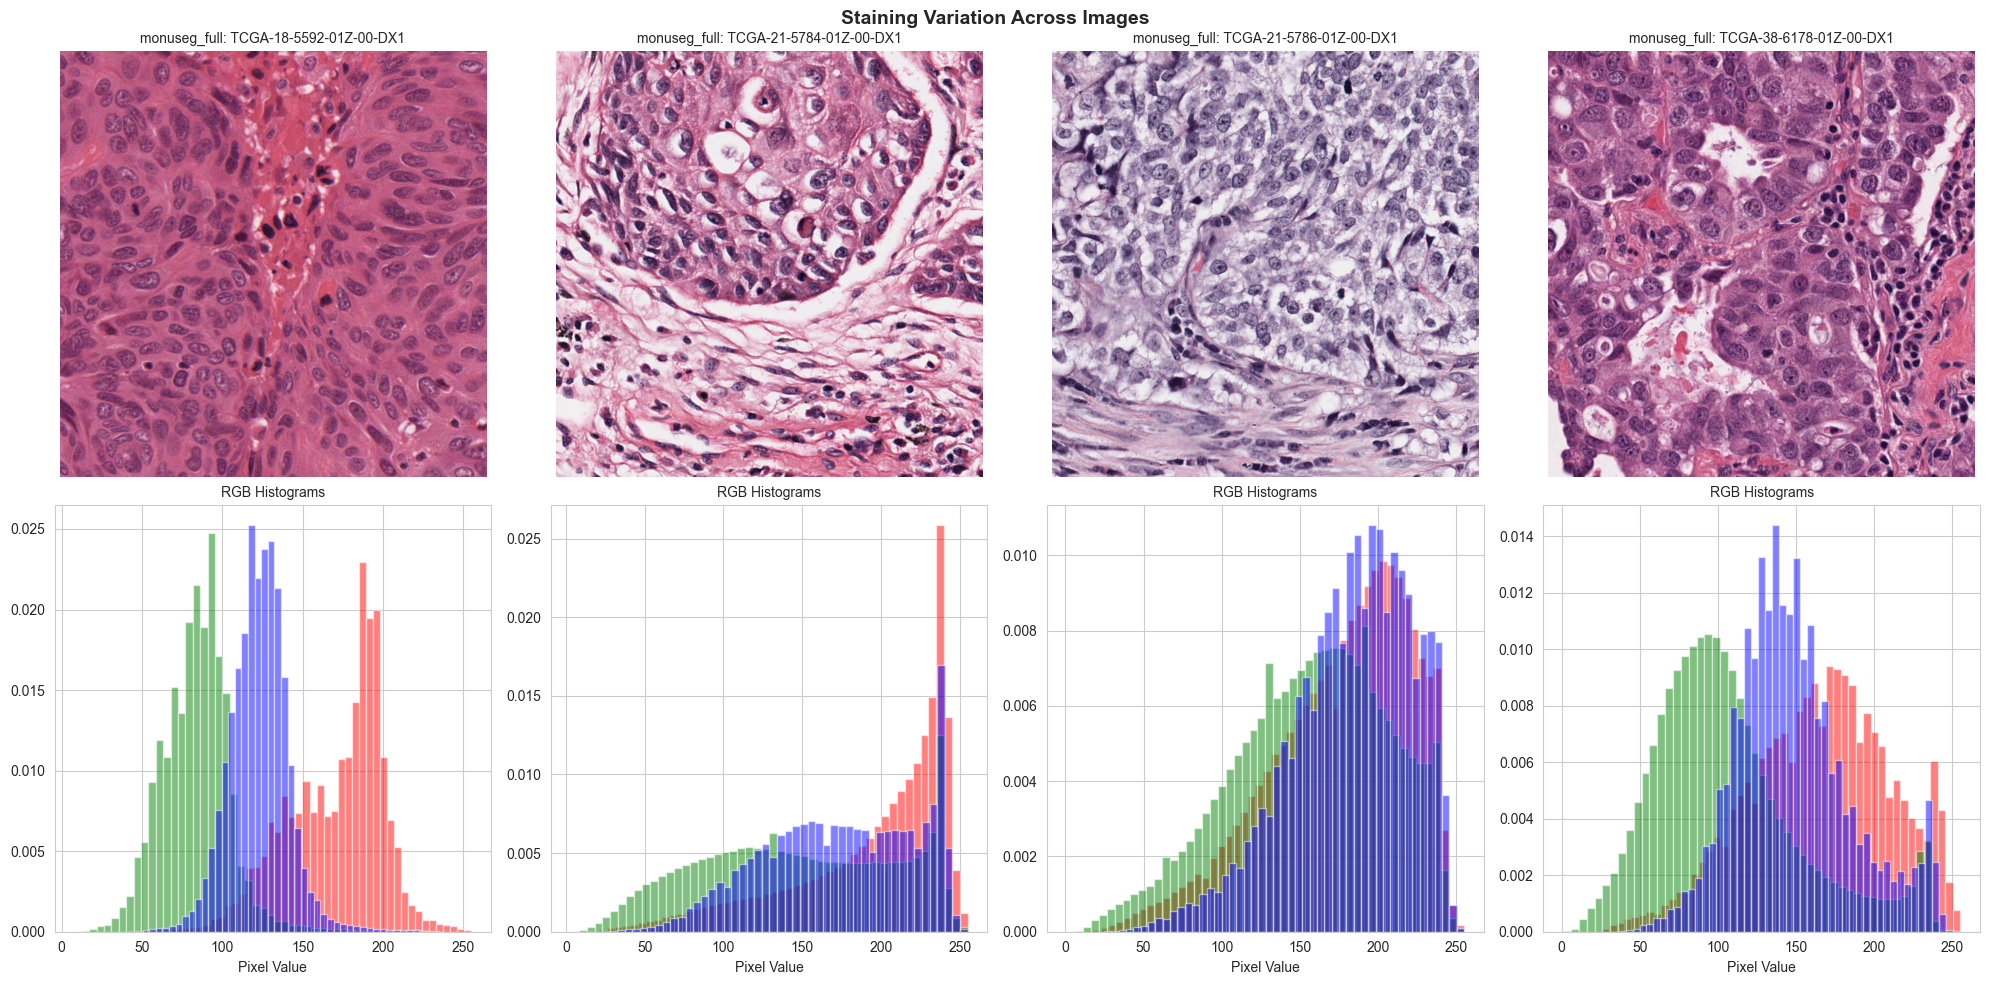


Notice how colors vary between images - this is the staining variation problem.
Stain normalization aims to make all images look like they came from the same lab.


In [9]:
# Robust bootstrap (allows running this cell without running previous cells)
import sys
if '..' not in sys.path:
    sys.path.insert(0, '..')

if 'np' not in globals():
    import numpy as np
if 'plt' not in globals():
    import matplotlib.pyplot as plt
if 'label' not in globals() or 'regionprops' not in globals():
    from skimage.measure import label, regionprops
if 'load_dataset' not in globals():
    from src.utils.data_loader import load_dataset
if 'DATA_ROOT' not in globals():
    DATA_ROOT = '../../data'
if 'datasets' not in globals():
    images_all, masks_all, names_all = load_dataset(DATA_ROOT, 'monuseg_full')
    datasets = {'monuseg_full': {'images': images_all, 'masks': masks_all, 'names': names_all}}

# Show staining variation across images
all_images = []
all_labels = []
for ds_name, data in datasets.items():
    for i, (img, name) in enumerate(zip(data['images'][:4], data['names'][:4])):
        all_images.append(img)
        all_labels.append(f"{ds_name}: {name}")

n = len(all_images)
fig, axes = plt.subplots(2, min(n, 4), figsize=(5*min(n, 4), 10))

for i in range(min(n, 4)):
    axes[0, i].imshow(all_images[i])
    axes[0, i].set_title(all_labels[i], fontsize=10)
    axes[0, i].axis('off')
    
    # Show mean color patch
    mean_color = all_images[i].mean(axis=(0,1)).astype(np.uint8)
    color_patch = np.full((50, 50, 3), mean_color, dtype=np.uint8)
    
    # Histogram of all channels
    for ch, color in enumerate(['red', 'green', 'blue']):
        axes[1, i].hist(all_images[i][:,:,ch].ravel(), bins=50, 
                       alpha=0.5, color=color, density=True)
    axes[1, i].set_title(f'RGB Histograms', fontsize=10)
    axes[1, i].set_xlabel('Pixel Value')

plt.suptitle('Staining Variation Across Images', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nNotice how colors vary between images - this is the staining variation problem.")
print("Stain normalization aims to make all images look like they came from the same lab.")